In [1]:
import numpy as np
from astropy import constants as const
import matplotlib.pyplot as plt
import scienceplots
from classy import Class
from scipy.integrate import solve_ivp
import VP_pert as vp_pt

plt.style.use(['science', 'bright'])

tex_fonts = {
    # Use 10pt or 11pt font to match the document
    "axes.labelsize": 12,
    "font.size": 12,
    # Make the legend/ticks slightly smaller
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

thesis_width = 472.03123

In [2]:
def set_size(width, fraction=1, subplots=(1, 1)):
    """
    Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    -----a-----
    width: float
            Document textwidth in pts
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

fig_dims = set_size(thesis_width)

# Matter only Universe

In [3]:
pars = vp_pt.cosmo_parameters

# Disable DE for matter only universe
# pars['Omega_m0'] = 1

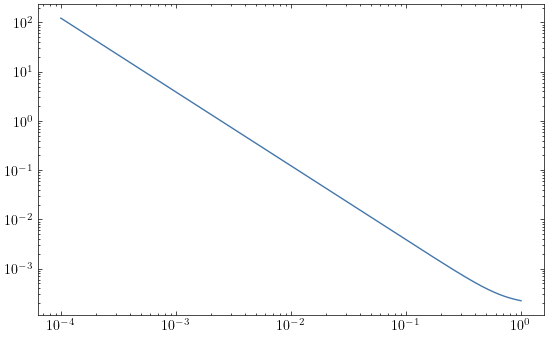

In [4]:
# Plot Hubble

aa = np.linspace(1e-4, 1, 1000)

fig, ax = plt.subplots(figsize=fig_dims)

ax.loglog(aa, vp_pt.Hubble(aa, pars=pars))

Error in callback <function _draw_all_if_interactive at 0x7b0afb414180> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

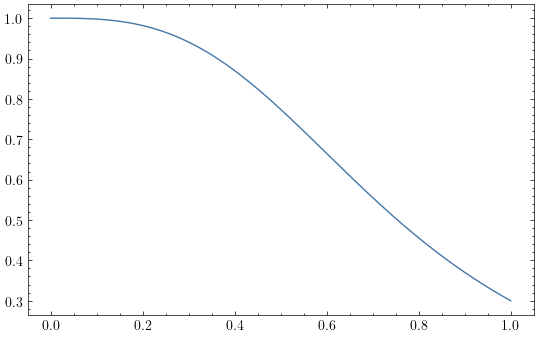

In [5]:
# Plot Omega_m

aa = np.linspace(1e-4, 1, 1000)

fig, ax = plt.subplots(figsize=fig_dims)

ax.plot(aa, vp_pt.Omega_m(aa, pars=pars))

In [ ]:
# Define array containing the wavenumbers where we will compute perturbations
kk = np.array([.1 * pars['H0 (1/Mpc)'], 1e-3, 1e-2, 1e-1, .5, 1])

In [ ]:
a_ini, a_end = 1e-4, 1.0
phi_ini = -1e-5

X_ivp = {}

for k in kk:
    H_ini = vp_pt.Hubble(a_ini, pars)
    H_conf = a_ini * H_ini
    
    delta_ini = -2 * phi_ini * (1 + k**2 / (3 * H_conf**2))
    vm_ini = (2 * k**2 / (3 * H_conf)) * phi_ini
    
    X0 = [delta_ini, vm_ini, 0.0, 0.0, phi_ini]

    X_ivp[k] = solve_ivp(vp_pt.rhs_pert,
                        t_span=(a_ini, a_end),
                        y0=X0,
                        method='RK45', 
                        dense_output=True,
                        t_eval=aa,
                        args=(k, pars))

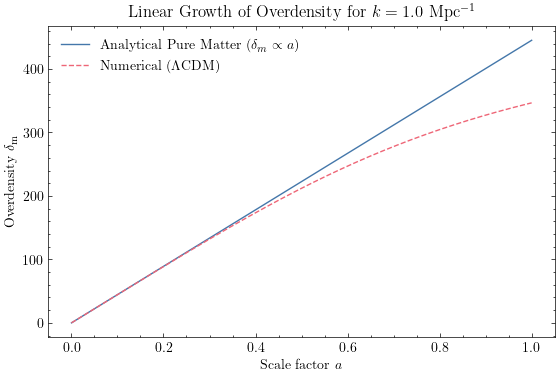

In [ ]:
fig, ax = plt.subplots(figsize=fig_dims) # Adjust size as needed for your LaTeX document
k = kk[-1] # k=1.0 Mpc^-1

# 1. Extract your numerical solution
a_num = X_ivp[k].t
delta_num = X_ivp[k].y[0]

# 2. Calculate the analytical Matter-Only solution
# In a pure matter universe, delta scales exactly as 'a'. 
# We anchor it to your exact initial conditions so they start at the same point!
delta_ini = delta_num[0]
a_ini = a_num[0]
delta_analytical = delta_ini * (a_num / a_ini)

# 3. Plot both solutions
ax.plot(a_num, delta_analytical, label=r'Analytical Pure Matter ($\delta_m \propto a$)')
ax.plot(a_num, delta_num, '--', label=r'Numerical ($\Lambda$CDM)')

# 4. Make it look professional for a thesis
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'Overdensity $\delta_\mathrm{m}$')
ax.set_title(rf'Linear Growth of Overdensity for $k={k}$ Mpc$^{{-1}}$')

ax.legend(loc='best')
# ax.grid(True, linestyle=':', alpha=0.6)

# Restrict the x-axis from 0 to 1 so the late-time bending is incredibly obvious
# ax.set_xlim(0, 1.05)
# ax.set_ylim(0, max(delta_analytical)*1.04)
fig.savefig('Perturbations.pdf')

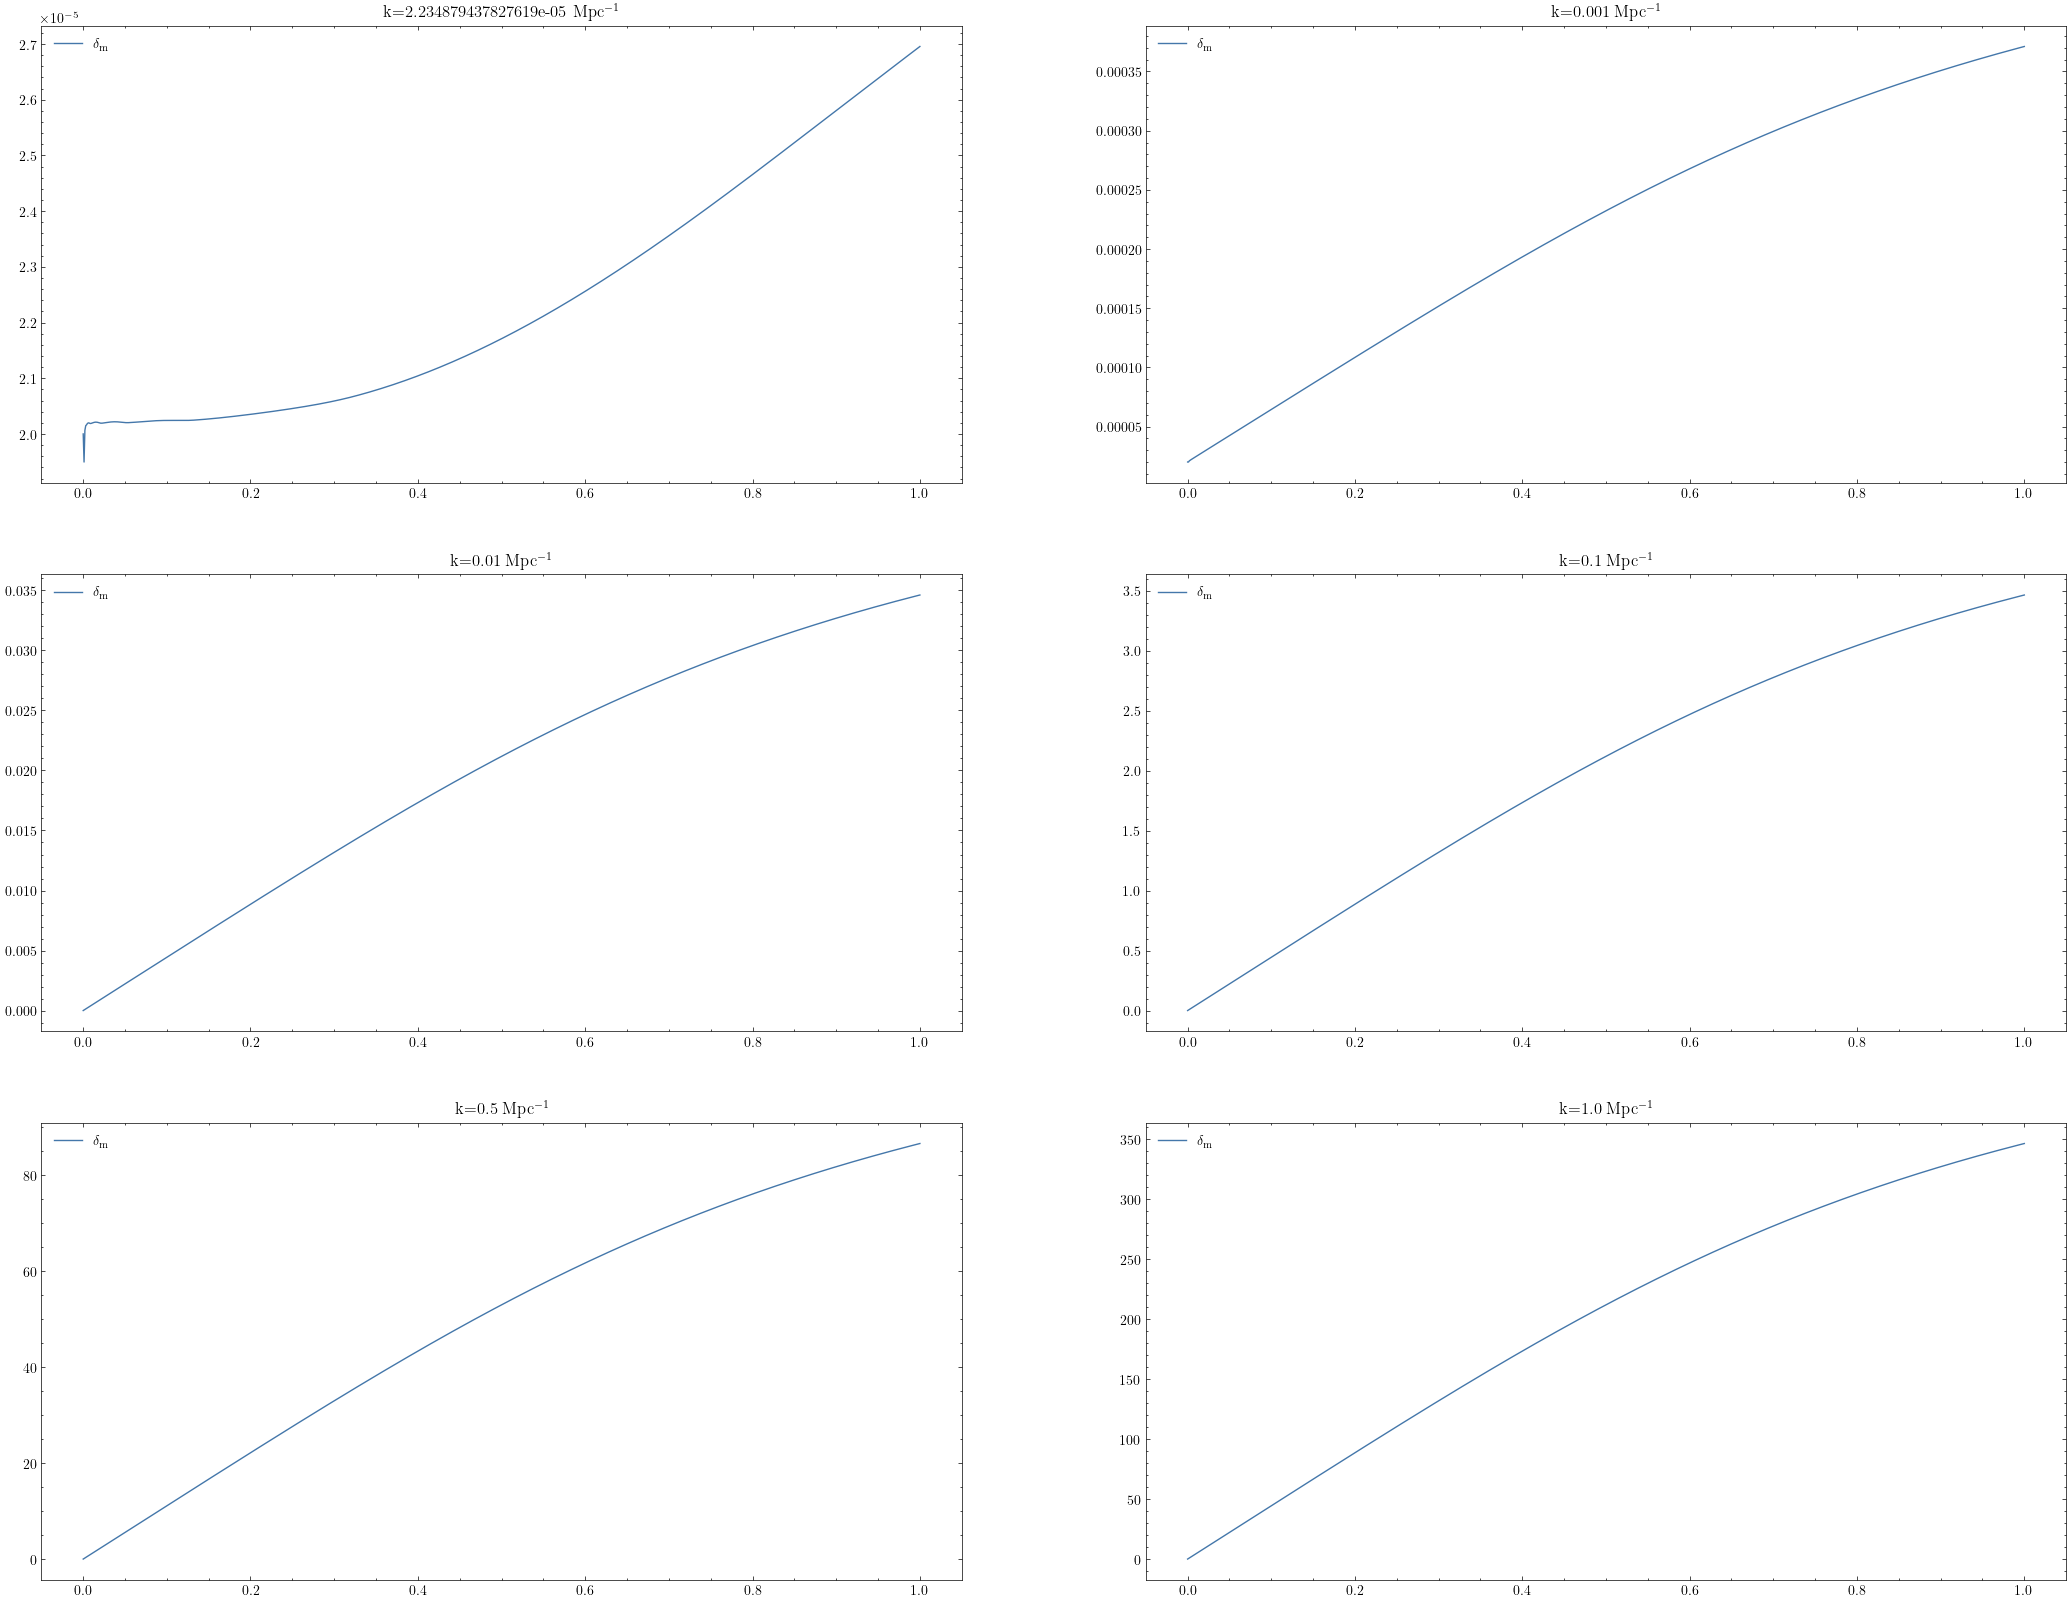

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(fig_dims[0]*4, fig_dims[1]*5))
ax = ax.flatten()

for idx, k in enumerate(kk):
    ax[idx].plot(X_ivp[k].t, X_ivp[k].y[0], label=r'$\delta_\text{m}$')
    # ax[idx].plot(X_ivp[k].t, X_ivp[k].y[1], label=r'$v_\text{m}$')
    # ax[idx].plot(X_ivp[k].t, X_ivp[k].y[2], label=r'$\delta_\text{DE}$')
    # ax[idx].plot(X_ivp[k].t, X_ivp[k].y[3], label=r'$v_\text{DE}$')
    # ax[idx].plot(X_ivp[k].t, X_ivp[k].y[4], label=r'$\phi$')
    ax[idx].legend()
    ax[idx].set_title(f'k={k} 'r'Mpc$^{-1}$')